# Notebook 03 — Multi-Factor Prepayment Model

## Fixed Income From Scratch

**Objective:** Build a rate-driven, econometric prepayment model that decomposes borrower behavior into its economic components.

### Why This Matters:
In Notebook 02, we used constant CPR and PSA — deterministic assumptions with no link to interest rates. But in reality, prepayment behavior is driven BY rates. When rates fall, refinancing surges. When rates rise, prepayments collapse to pure turnover. A model that captures this rate-dependence is essential for:
- **OAS calculation** (Notebook 07): each Monte Carlo path needs its own prepayment projection
- **Duration/convexity**: rate sensitivity must account for how prepayments change WITH rates
- **Relative value**: understanding whether a pool's actual speeds justify its price

### The Four Components:
1. **Refinancing** — S-curve response to rate incentive (the dominant factor)
2. **Turnover** — Rate-independent housing mobility (baseline prepayment)
3. **Burnout** — Declining sensitivity as rate-responsive borrowers leave the pool
4. **Aging** — Seasoning ramp for new originations

### Total CPR = Refinancing × Burnout + Turnover × Aging × Seasonality

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys, os

sys.path.insert(0, os.path.abspath('..'))
from utils.prepayment_model import (
    PrepaymentTuning, PrepaymentModelResult,
    refinancing_component, turnover_component, burnout_factor, aging_ramp,
    project_prepayment_rates, plot_scurve_data, compute_speed_table,
    calibration_error, generate_synthetic_historical_speeds,
    fast_prepay_tuning, slow_prepay_tuning, seasoned_discount_tuning
)
from utils.prepayment import cpr_to_smm, psa_to_cpr

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("Multi-factor prepayment model loaded.")

Multi-factor prepayment model loaded.


---
## 1. The Refinancing S-Curve

The refinancing incentive is the single most important driver of MBS prepayments. It's defined as:

**Incentive = Borrower's Note Rate − Current Market Mortgage Rate**

When incentive > 0 (rates have fallen), borrowers can refinance into a lower rate. But the response is **nonlinear**:
- Below ~50bp: transaction costs outweigh savings — almost no one refinances
- 50-150bp: rapid acceleration — this is the "elbow" where refinancing takes off
- Above 200bp: saturation — the most rate-sensitive borrowers have already left

We model this with a **logistic (S-curve) function**, parameterized by:
- **Midpoint**: incentive level where response = 50% of maximum
- **Steepness**: how sharply the curve transitions
- **Maximum CPR**: saturation level
- **Elbow shift**: allows tuning where the curve inflects

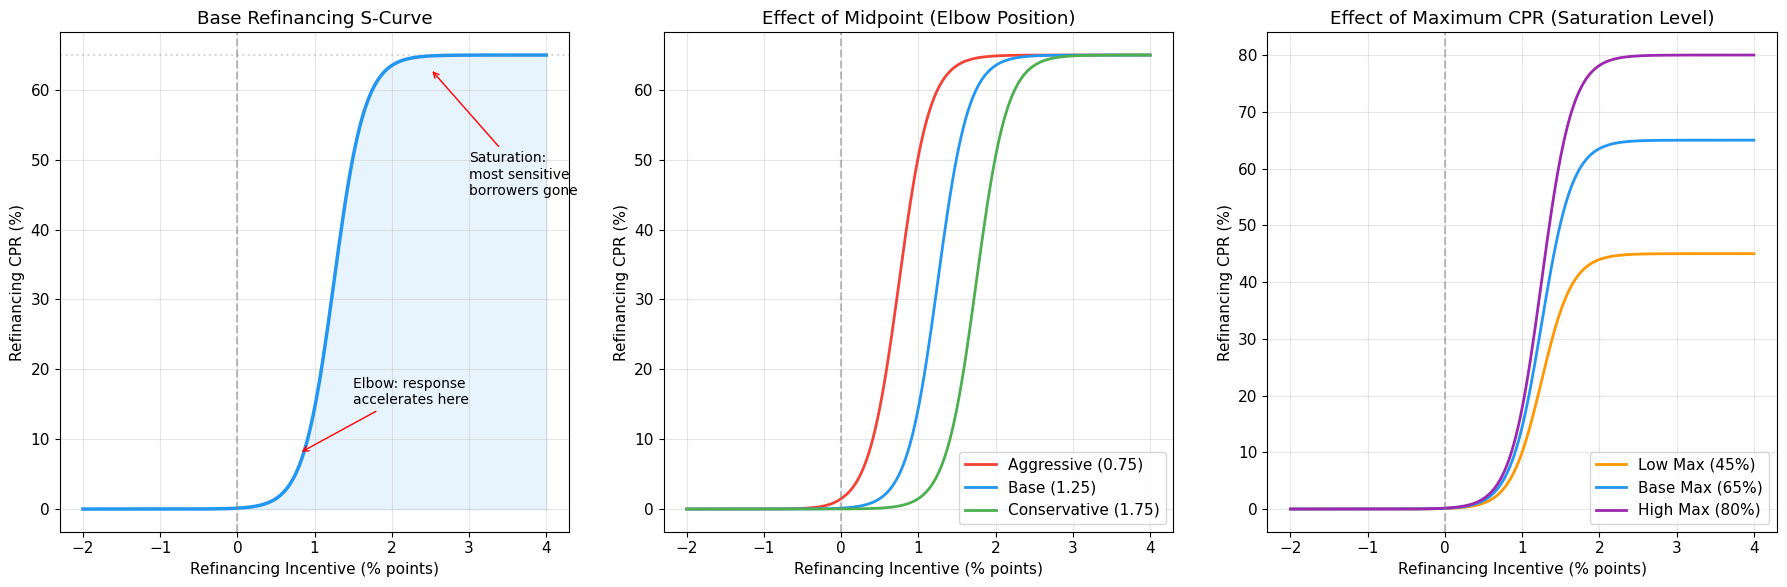

The S-curve shape is the most important thing to get right in a prepayment model.
Moving the elbow left (aggressive) means borrowers respond to smaller incentives.
Moving it right (conservative) means they need larger incentives to refinance.


In [5]:
# Visualize the S-curve under different tuning scenarios
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Base S-curve
ax = axes[0]
base = plot_scurve_data(PrepaymentTuning())
ax.plot(base['incentives'], base['refi_cprs'], linewidth=2.5, color='#2196F3')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=65, color='gray', linestyle=':', alpha=0.3)
ax.fill_between(base['incentives'], 0, base['refi_cprs'], alpha=0.1, color='#2196F3')
ax.set_xlabel('Refinancing Incentive (% points)')
ax.set_ylabel('Refinancing CPR (%)')
ax.set_title('Base Refinancing S-Curve')
ax.annotate('Elbow: response\naccelerates here', xy=(0.8, 8), xytext=(1.5, 15),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))
ax.annotate('Saturation:\nmost sensitive\nborrowers gone', xy=(2.5, 63), xytext=(3, 45),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

# Different midpoints (elbow sensitivity)
ax = axes[1]
for midpoint, label, color in [(0.75, 'Aggressive (0.75)', '#F44336'),
                                 (1.25, 'Base (1.25)', '#2196F3'),
                                 (1.75, 'Conservative (1.75)', '#4CAF50')]:
    tuning = PrepaymentTuning(refi_midpoint=midpoint)
    data = plot_scurve_data(tuning)
    ax.plot(data['incentives'], data['refi_cprs'], linewidth=2, label=label, color=color)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Refinancing Incentive (% points)')
ax.set_ylabel('Refinancing CPR (%)')
ax.set_title('Effect of Midpoint (Elbow Position)')
ax.legend()

# Different max CPRs
ax = axes[2]
for max_cpr, label, color in [(0.45, 'Low Max (45%)', '#FF9800'),
                                (0.65, 'Base Max (65%)', '#2196F3'),
                                (0.80, 'High Max (80%)', '#9C27B0')]:
    tuning = PrepaymentTuning(refi_max_cpr=max_cpr)
    data = plot_scurve_data(tuning)
    ax.plot(data['incentives'], data['refi_cprs'], linewidth=2, label=label, color=color)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Refinancing Incentive (% points)')
ax.set_ylabel('Refinancing CPR (%)')
ax.set_title('Effect of Maximum CPR (Saturation Level)')
ax.legend()

plt.tight_layout()
plt.show()

print("The S-curve shape is the most important thing to get right in a prepayment model.")
print("Moving the elbow left (aggressive) means borrowers respond to smaller incentives.")
print("Moving it right (conservative) means they need larger incentives to refinance.")

---
## 2. Component Decomposition

Let's visualize each component independently before combining them.

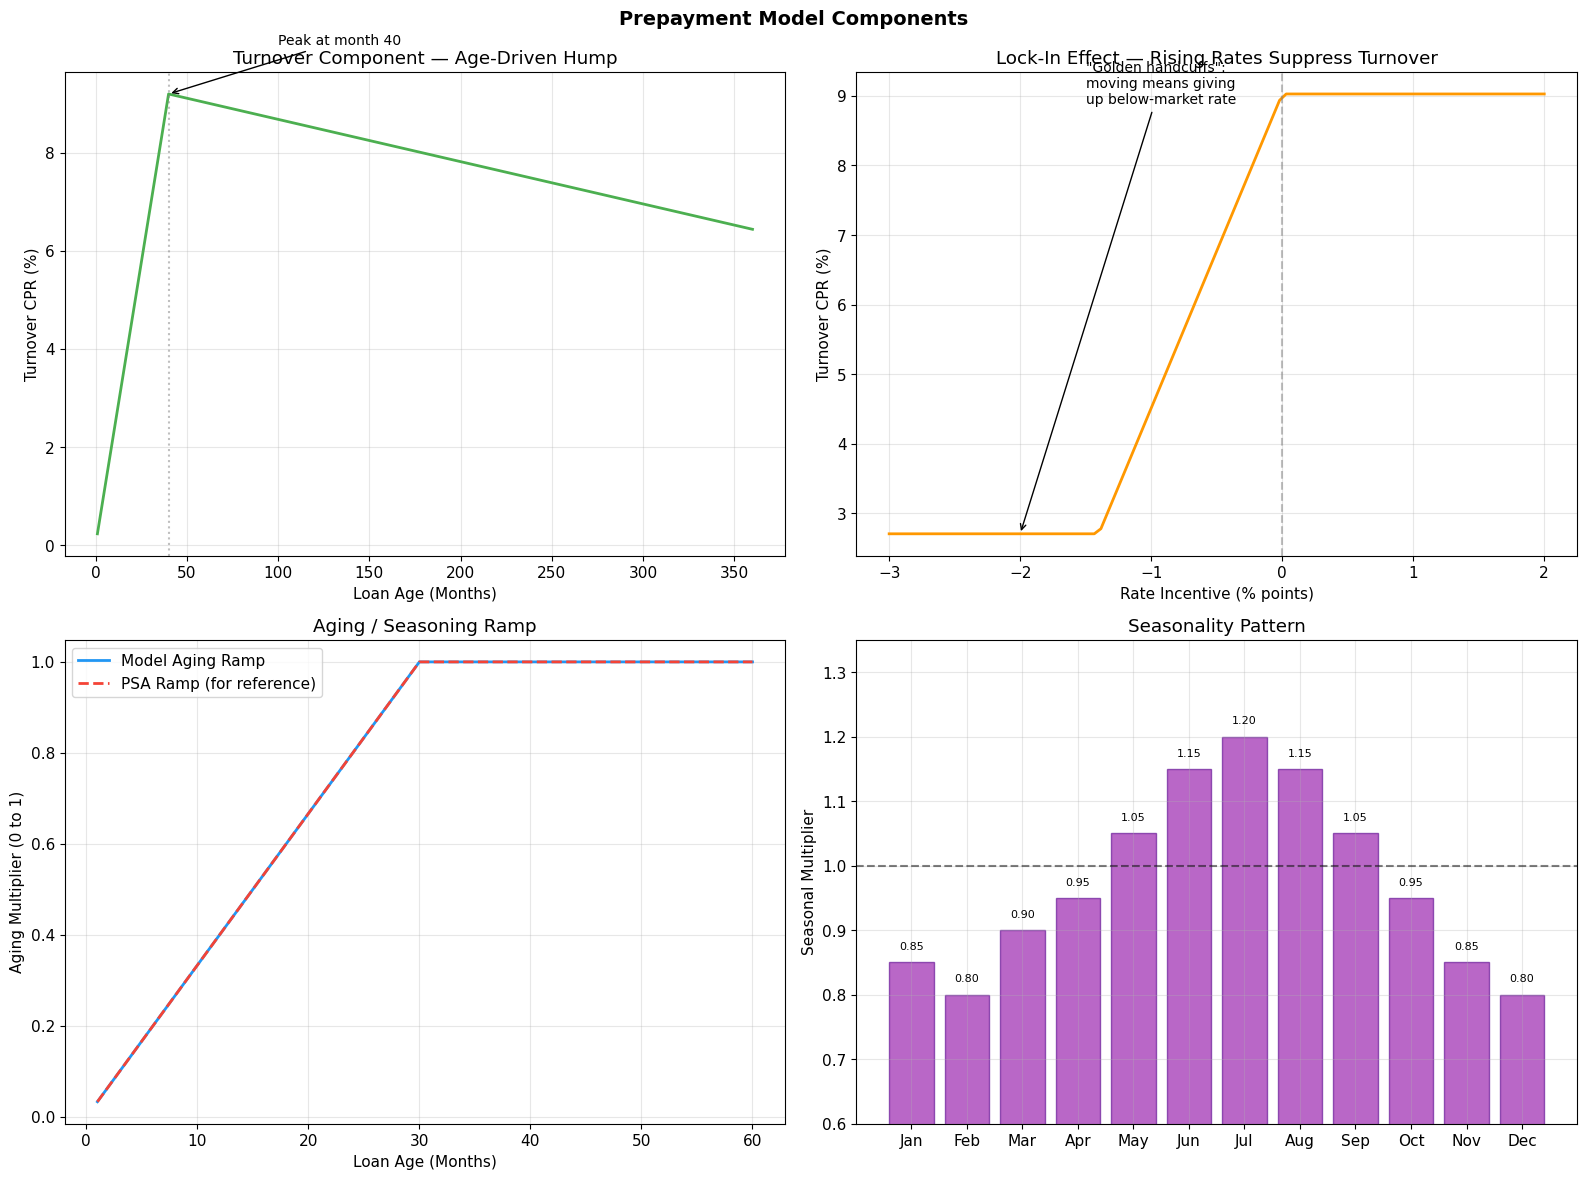

Each component captures a distinct economic driver of prepayment behavior.
The total model combines them: CPR = Refi × Burnout + Turnover × Aging × Season


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
tuning = PrepaymentTuning()

# Turnover hump shape
ax = axes[0, 0]
ages = np.arange(1, 361)
turn_cprs = np.array([turnover_component(a, 0, tuning, 6) for a in ages])
ax.plot(ages, turn_cprs * 100, linewidth=2, color='#4CAF50')
ax.axvline(x=40, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Loan Age (Months)')
ax.set_ylabel('Turnover CPR (%)')
ax.set_title('Turnover Component — Age-Driven Hump')
ax.annotate(f'Peak at month {tuning.turnover_peak_month}', xy=(40, turn_cprs[39]*100),
            xytext=(100, turn_cprs[39]*100 + 1), fontsize=10,
            arrowprops=dict(arrowstyle='->'))

# Lock-in effect on turnover
ax = axes[0, 1]
incentives_lockn = np.linspace(-3, 2, 100)
turn_by_inc = np.array([turnover_component(60, inc, tuning, 6) for inc in incentives_lockn])
ax.plot(incentives_lockn, turn_by_inc * 100, linewidth=2, color='#FF9800')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Rate Incentive (% points)')
ax.set_ylabel('Turnover CPR (%)')
ax.set_title('Lock-In Effect — Rising Rates Suppress Turnover')
ax.annotate('"Golden handcuffs":\nmoving means giving\nup below-market rate',
            xy=(-2, turn_by_inc[20]*100), xytext=(-1.5, turn_by_inc[50]*100 + 2),
            fontsize=10, arrowprops=dict(arrowstyle='->'))

# Aging ramp
ax = axes[1, 0]
ramp = np.array([aging_ramp(a, tuning) for a in ages[:60]])
psa_100 = np.array([min(a * 0.002 / 0.06, 1.0) for a in range(1, 61)])
ax.plot(np.arange(1, 61), ramp, linewidth=2, label='Model Aging Ramp', color='#2196F3')
ax.plot(np.arange(1, 61), psa_100, '--', linewidth=2, label='PSA Ramp (for reference)', color='#F44336')
ax.set_xlabel('Loan Age (Months)')
ax.set_ylabel('Aging Multiplier (0 to 1)')
ax.set_title('Aging / Seasoning Ramp')
ax.legend()

# Seasonality
ax = axes[1, 1]
months_cal = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bars = ax.bar(months_cal, tuning.seasonality, color='#9C27B0', alpha=0.7, edgecolor='#6A1B9A')
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
ax.set_ylabel('Seasonal Multiplier')
ax.set_title('Seasonality Pattern')
ax.set_ylim(0.6, 1.35)
for bar, val in zip(bars, tuning.seasonality):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', 
            ha='center', fontsize=8)

plt.suptitle('Prepayment Model Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each component captures a distinct economic driver of prepayment behavior.")
print("The total model combines them: CPR = Refi × Burnout + Turnover × Aging × Season")

---
## 3. Full Model Projection — Rate Scenarios

Now we project prepayments under different rate environments. This is where the model proves its value: unlike constant CPR or PSA, the model's output CHANGES with rates.

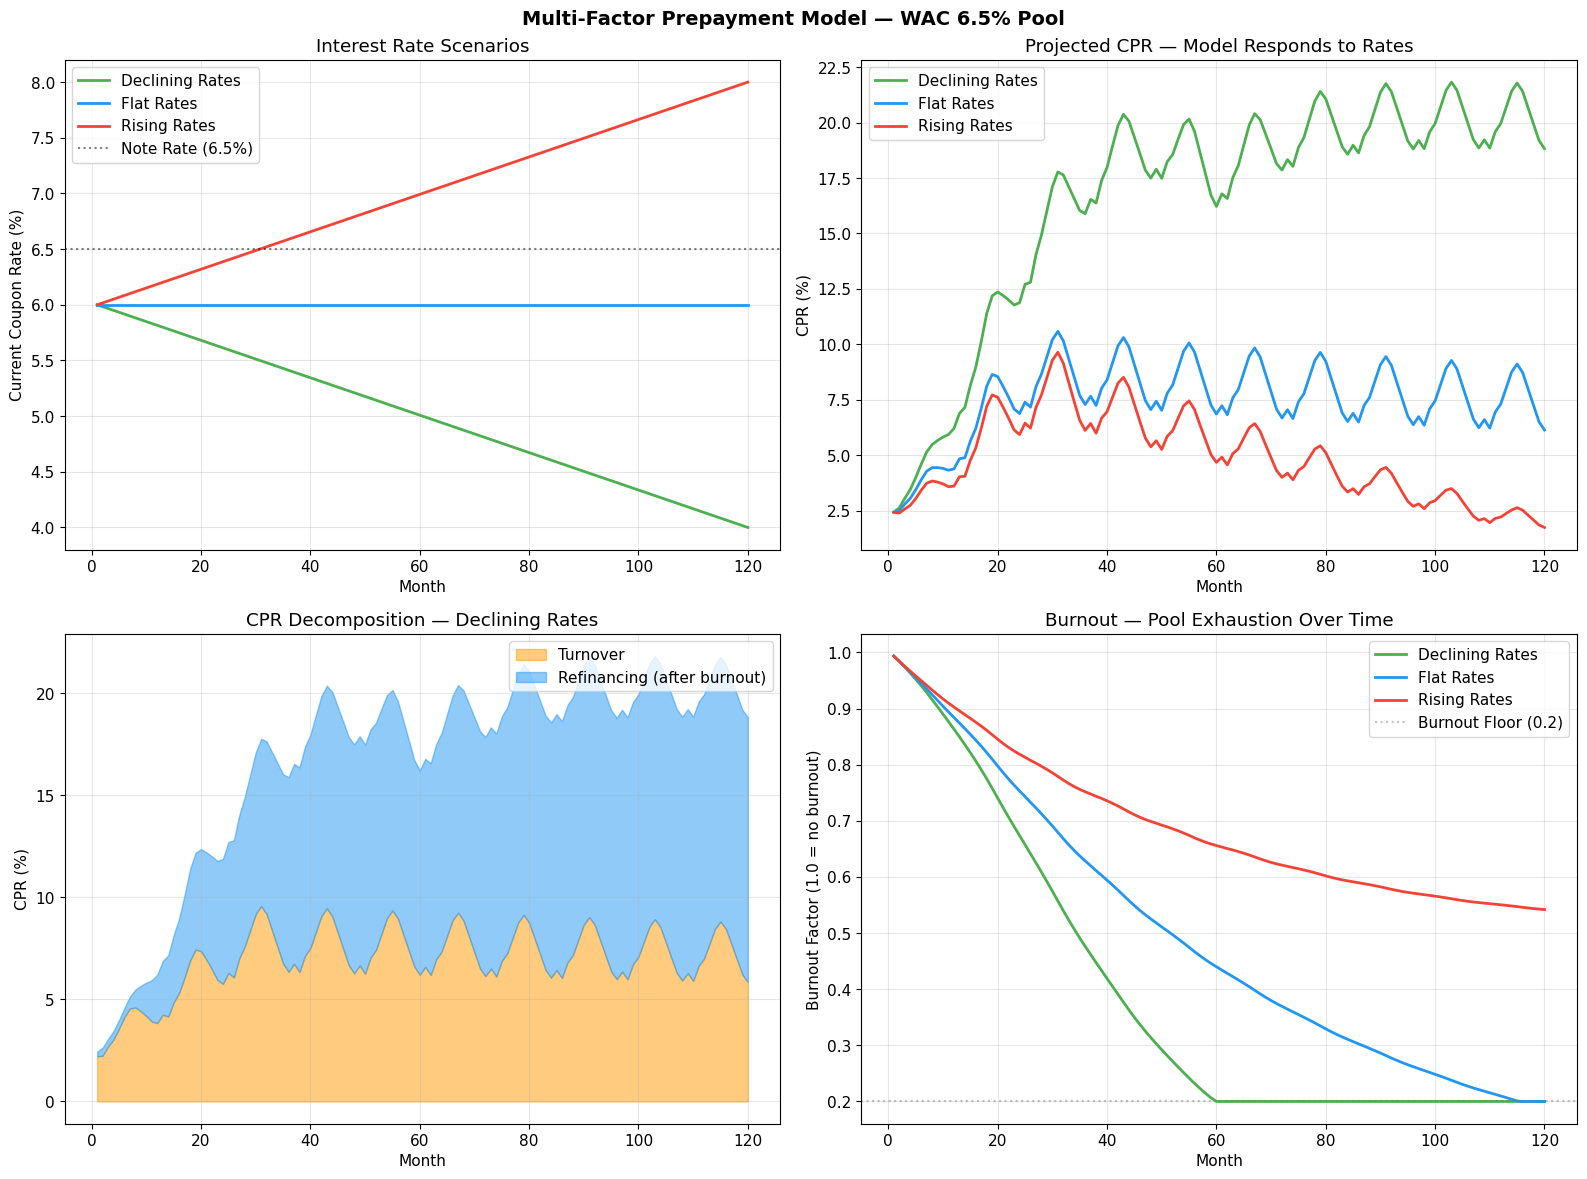

KEY OBSERVATIONS:
  Declining rates: CPR peaks at 21.8%, then falls as pool burns out
  Flat rates:      CPR stabilizes around 6.9% (mostly turnover)
  Rising rates:    CPR drops to 4.7% (lock-in effect suppresses turnover)

Burnout in declining scenario: factor drops from 0.99 to 0.200
The remaining borrowers are almost completely unresponsive to further rate declines.


In [11]:
# Project under three rate scenarios
note_rate = 0.065
n_months = 120
months = np.arange(1, n_months + 1)
tuning = PrepaymentTuning()

# Scenario 1: Rates fall 200bp (strong refi incentive)
cc_declining = note_rate - 0.005 - np.linspace(0, 0.02, n_months)
res_decline = project_prepayment_rates(note_rate, cc_declining, n_months, loan_age=12, tuning=tuning)

# Scenario 2: Rates flat (moderate refi incentive from existing spread)
cc_flat = np.full(n_months, note_rate - 0.005)
res_flat = project_prepayment_rates(note_rate, cc_flat, n_months, loan_age=12, tuning=tuning)

# Scenario 3: Rates rise 200bp (no refi incentive, lock-in)
cc_rising = note_rate - 0.005 + np.linspace(0, 0.02, n_months)
res_rise = project_prepayment_rates(note_rate, cc_rising, n_months, loan_age=12, tuning=tuning)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Rate paths
ax = axes[0, 0]
ax.plot(months, cc_declining * 100, label='Declining Rates', linewidth=2, color='#4CAF50')
ax.plot(months, cc_flat * 100, label='Flat Rates', linewidth=2, color='#2196F3')
ax.plot(months, cc_rising * 100, label='Rising Rates', linewidth=2, color='#F44336')
ax.axhline(y=note_rate * 100, color='black', linestyle=':', alpha=0.5, label=f'Note Rate ({note_rate*100}%)')
ax.set_xlabel('Month')
ax.set_ylabel('Current Coupon Rate (%)')
ax.set_title('Interest Rate Scenarios')
ax.legend()

# Total CPR
ax = axes[0, 1]
ax.plot(months, res_decline.total_cpr * 100, label='Declining Rates', linewidth=2, color='#4CAF50')
ax.plot(months, res_flat.total_cpr * 100, label='Flat Rates', linewidth=2, color='#2196F3')
ax.plot(months, res_rise.total_cpr * 100, label='Rising Rates', linewidth=2, color='#F44336')
ax.set_xlabel('Month')
ax.set_ylabel('CPR (%)')
ax.set_title('Projected CPR — Model Responds to Rates')
ax.legend()

# Component decomposition for declining rates
ax = axes[1, 0]
ax.fill_between(months, 0, res_decline.turnover_cpr * 100, alpha=0.5, label='Turnover', color='#FF9800')
ax.fill_between(months, res_decline.turnover_cpr * 100, res_decline.total_cpr * 100, alpha=0.5, label='Refinancing (after burnout)', color='#2196F3')
ax.set_xlabel('Month')
ax.set_ylabel('CPR (%)')
ax.set_title('CPR Decomposition — Declining Rates')
ax.legend()

# Burnout effect
ax = axes[1, 1]
ax.plot(months, res_decline.burnout_factors, label='Declining Rates', linewidth=2, color='#4CAF50')
ax.plot(months, res_flat.burnout_factors, label='Flat Rates', linewidth=2, color='#2196F3')
ax.plot(months, res_rise.burnout_factors, label='Rising Rates', linewidth=2, color='#F44336')
ax.axhline(y=tuning.burnout_floor, color='gray', linestyle=':', alpha=0.5, label=f'Burnout Floor ({tuning.burnout_floor})')
ax.set_xlabel('Month')
ax.set_ylabel('Burnout Factor (1.0 = no burnout)')
ax.set_title('Burnout — Pool Exhaustion Over Time')
ax.legend()

plt.suptitle(f'Multi-Factor Prepayment Model — WAC {note_rate*100}% Pool', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("KEY OBSERVATIONS:")
print(f"  Declining rates: CPR peaks at {res_decline.total_cpr.max()*100:.1f}%, then falls as pool burns out")
print(f"  Flat rates:      CPR stabilizes around {res_flat.total_cpr[59]*100:.1f}% (mostly turnover)")
print(f"  Rising rates:    CPR drops to {res_rise.total_cpr[59]*100:.1f}% (lock-in effect suppresses turnover)")
print(f"\nBurnout in declining scenario: factor drops from {res_decline.burnout_factors[0]:.2f} to {res_decline.burnout_factors[-1]:.3f}")
print("The remaining borrowers are almost completely unresponsive to further rate declines.")

---
## 4. Speed Table (S-Curve Table)

The speed table shows projected CPR across a range of rate scenarios — this is the standard tool traders use to understand a pool's prepayment sensitivity at a point in time.

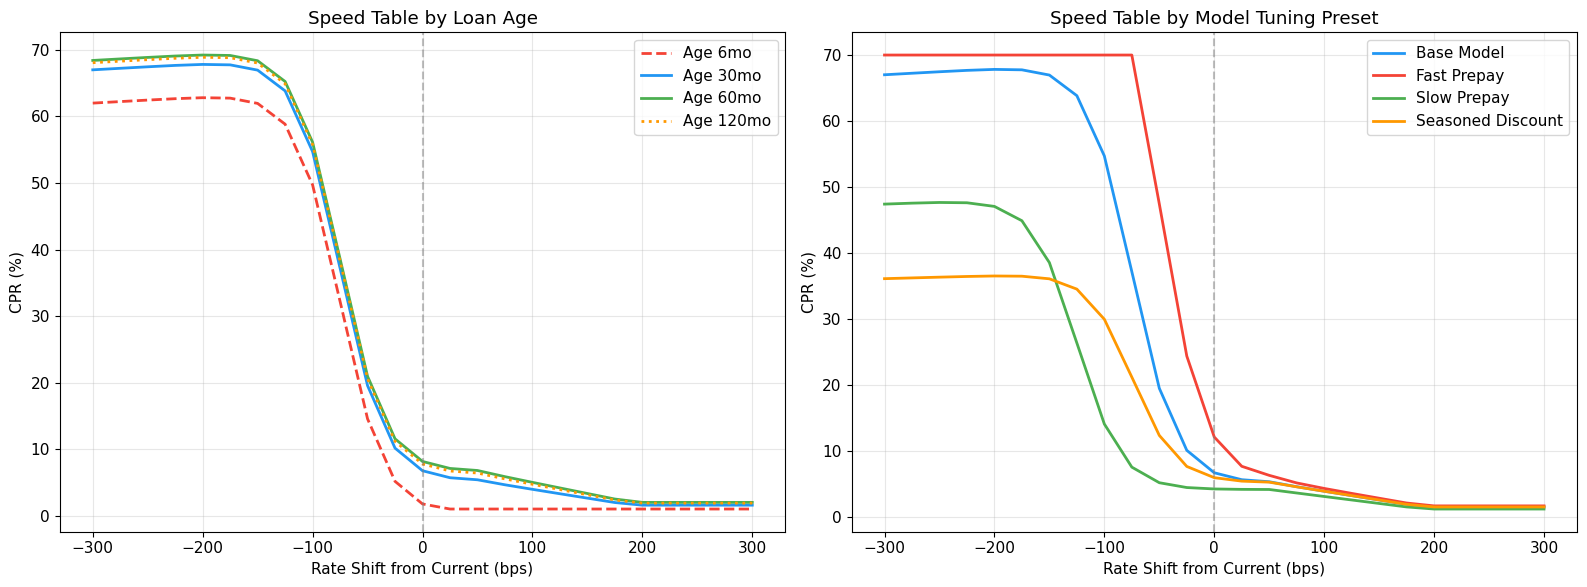

Speed Table — WAC 6.5%, Age 30 months, Base Tuning
 Shift (bps)  CC Rate (%)    CPR (%)    SMM (%)
-------------------------------------------------------
        -200         4.00      67.83     9.0172
        -150         4.50      66.97     8.8174
        -100         5.00      54.72     6.3901
         -50         5.50      19.55     1.7960
          +0         6.00       6.75     0.5810
         +50         6.50       5.40     0.4611
        +100         7.00       3.96     0.3362
        +150         7.50       2.64     0.2223
        +200         8.00       1.58     0.1327


In [14]:
# Generate speed table
shifts = np.arange(-300, 301, 25)
tuning = PrepaymentTuning()

# Speed tables at different loan ages (seasoning matters)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for age, color, ls in [(6, '#F44336', '--'), (30, '#2196F3', '-'), (60, '#4CAF50', '-'), (120, '#FF9800', ':')]:
    speeds = compute_speed_table(0.065, shifts, loan_age=age, tuning=tuning)
    ax1.plot(speeds['shifts_bps'], speeds['cprs'] * 100, ls, label=f'Age {age}mo', linewidth=2, color=color)

ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Rate Shift from Current (bps)')
ax1.set_ylabel('CPR (%)')
ax1.set_title('Speed Table by Loan Age')
ax1.legend()

# Compare tuning presets
for tuning_preset, label, color in [
    (PrepaymentTuning(), 'Base Model', '#2196F3'),
    (fast_prepay_tuning(), 'Fast Prepay', '#F44336'),
    (slow_prepay_tuning(), 'Slow Prepay', '#4CAF50'),
    (seasoned_discount_tuning(), 'Seasoned Discount', '#FF9800')]:
    speeds = compute_speed_table(0.065, shifts, loan_age=30, tuning=tuning_preset)
    ax2.plot(speeds['shifts_bps'], speeds['cprs'] * 100, linewidth=2, label=label, color=color)

ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Rate Shift from Current (bps)')
ax2.set_ylabel('CPR (%)')
ax2.set_title('Speed Table by Model Tuning Preset')
ax2.legend()

plt.tight_layout()
plt.show()

# Print speed table
print("Speed Table — WAC 6.5%, Age 30 months, Base Tuning")
print("=" * 55)
speeds = compute_speed_table(0.065, np.arange(-200, 201, 50), loan_age=30, tuning=PrepaymentTuning())
print(f"{'Shift (bps)':>12} {'CC Rate (%)':>12} {'CPR (%)':>10} {'SMM (%)':>10}")
print("-" * 55)
for s, cc, cpr, smm in zip(speeds['shifts_bps'], speeds['current_coupons'], speeds['cprs'], speeds['smms']):
    print(f"{s:>+12.0f} {cc*100:>12.2f} {cpr*100:>10.2f} {smm*100:>10.4f}")

---
## 5. Model Calibration — Fitting to Historical Speeds

A prepayment model is only useful if it matches observed borrower behavior. In production, you'd calibrate against **Fannie Mae loan-level data** — monthly performance records for millions of loans.

Here we demonstrate the calibration methodology using synthetic historical data. The workflow is:
1. Observe actual pool CPRs over a historical period
2. Run the model with initial tuning parameters
3. Compare predicted vs actual speeds
4. Adjust tuning parameters to minimize the error
5. Validate on out-of-sample periods

The key diagnostic is the **Actual/Model ratio**: if it's consistently > 1, the model underpredicts; if < 1, it overpredicts. Persistent bias in one direction means a tuning parameter needs adjustment.

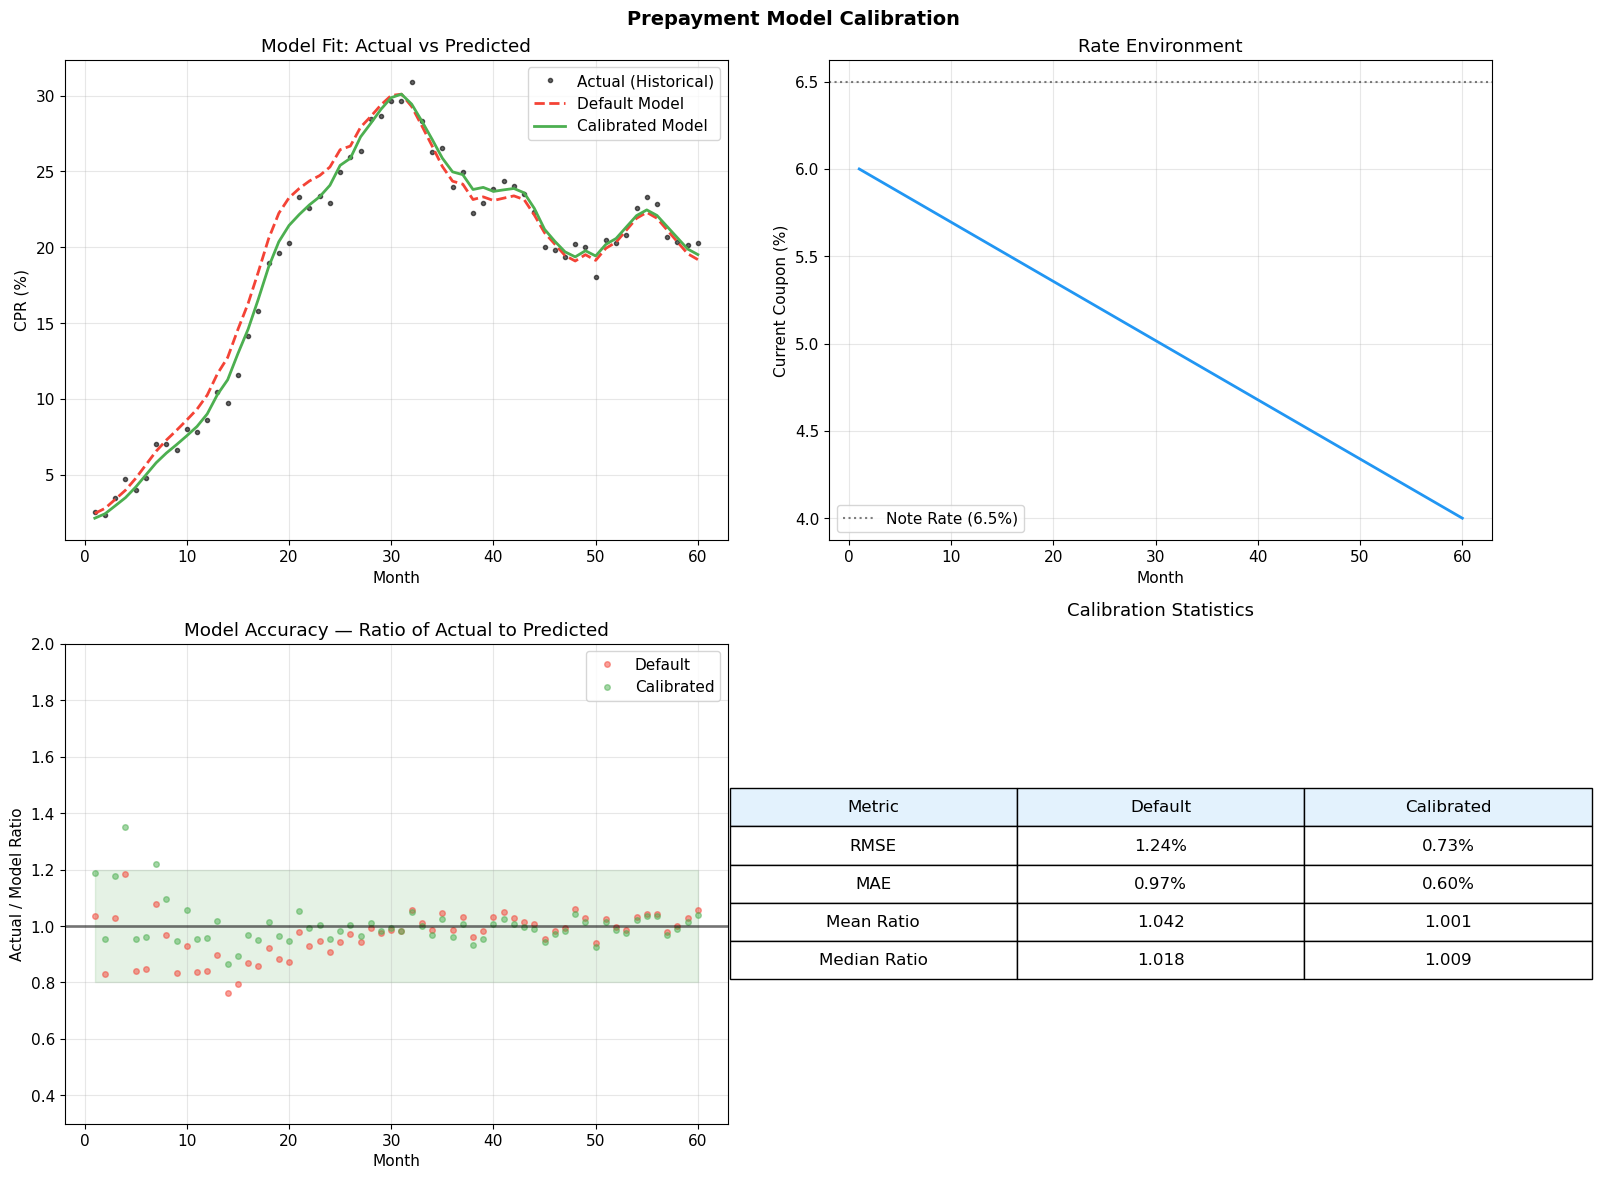

Default model RMSE: 1.24% CPR
Calibrated model RMSE: 0.73% CPR
Improvement: 41% reduction in RMSE


In [17]:
# Generate synthetic historical data (declining rates scenario)
hist = generate_synthetic_historical_speeds(
    note_rate=0.065, num_months=60, rate_path_type='declining', noise_std=0.008
)

# Run model with default tuning (intentionally mistuned)
default_tuning = PrepaymentTuning()  # Not the "true" parameters
default_result = project_prepayment_rates(
    note_rate=0.065, current_coupon_path=hist['rate_path'],
    num_months=60, loan_age=12, tuning=default_tuning
)

# Run with "calibrated" tuning (closer to true)
calibrated_tuning = PrepaymentTuning(
    refinancing_multiplier=1.05,
    turnover_multiplier=0.95,
    refi_midpoint=1.30,
)
calibrated_result = project_prepayment_rates(
    note_rate=0.065, current_coupon_path=hist['rate_path'],
    num_months=60, loan_age=12, tuning=calibrated_tuning
)

# Compute errors
err_default = calibration_error(hist['actual_cprs'], default_result.total_cpr)
err_calibrated = calibration_error(hist['actual_cprs'], calibrated_result.total_cpr)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Actual vs Model CPR
ax = axes[0, 0]
ax.plot(hist['months'], hist['actual_cprs'] * 100, 'ko', markersize=3, alpha=0.6, label='Actual (Historical)')
ax.plot(hist['months'], default_result.total_cpr * 100, '--', linewidth=2, label='Default Model', color='#F44336')
ax.plot(hist['months'], calibrated_result.total_cpr * 100, '-', linewidth=2, label='Calibrated Model', color='#4CAF50')
ax.set_xlabel('Month')
ax.set_ylabel('CPR (%)')
ax.set_title('Model Fit: Actual vs Predicted')
ax.legend()

# Rate path
ax = axes[0, 1]
ax.plot(hist['months'], hist['rate_path'] * 100, linewidth=2, color='#2196F3')
ax.axhline(y=6.5, color='black', linestyle=':', alpha=0.5, label='Note Rate (6.5%)')
ax.set_xlabel('Month')
ax.set_ylabel('Current Coupon (%)')
ax.set_title('Rate Environment')
ax.legend()

# Actual/Model ratios
ax = axes[1, 0]
ratios_def = np.where(default_result.total_cpr > 0.005, hist['actual_cprs'] / default_result.total_cpr, np.nan)
ratios_cal = np.where(calibrated_result.total_cpr > 0.005, hist['actual_cprs'] / calibrated_result.total_cpr, np.nan)
ax.plot(hist['months'], ratios_def, 'o', markersize=4, alpha=0.5, label='Default', color='#F44336')
ax.plot(hist['months'], ratios_cal, 'o', markersize=4, alpha=0.5, label='Calibrated', color='#4CAF50')
ax.axhline(y=1.0, color='black', linewidth=2, alpha=0.5)
ax.fill_between(hist['months'], 0.8, 1.2, alpha=0.1, color='green')
ax.set_xlabel('Month')
ax.set_ylabel('Actual / Model Ratio')
ax.set_title('Model Accuracy — Ratio of Actual to Predicted')
ax.set_ylim(0.3, 2.0)
ax.legend()

# Error comparison
ax = axes[1, 1]
ax.axis('off')
table_data = [
    ['Metric', 'Default', 'Calibrated'],
    ['RMSE', f'{err_default["rmse"]*100:.2f}%', f'{err_calibrated["rmse"]*100:.2f}%'],
    ['MAE', f'{err_default["mae"]*100:.2f}%', f'{err_calibrated["mae"]*100:.2f}%'],
    ['Mean Ratio', f'{err_default["mean_ratio"]:.3f}', f'{err_calibrated["mean_ratio"]:.3f}'],
    ['Median Ratio', f'{err_default["median_ratio"]:.3f}', f'{err_calibrated["median_ratio"]:.3f}'],
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0], loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 2.0)
for i in range(len(table_data[0])):
    table[0, i].set_facecolor('#E3F2FD')
ax.set_title('Calibration Statistics', fontsize=13, pad=20)

plt.suptitle('Prepayment Model Calibration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Default model RMSE: {err_default['rmse']*100:.2f}% CPR")
print(f"Calibrated model RMSE: {err_calibrated['rmse']*100:.2f}% CPR")
print(f"Improvement: {(1 - err_calibrated['rmse']/err_default['rmse'])*100:.0f}% reduction in RMSE")

---
## 6. Tuning Parameter Framework

The model supports saving and loading tuning parameter sets. In production, an MBS analyst maintains different tuning files for:
- **House view**: the firm's base case prepayment assumptions
- **Sector views**: different assumptions for different MBS cohorts (high LTV, jumbo, FHA, etc.)
- **Trade-specific**: custom tuning for relative value analysis
- **Stress scenarios**: aggressive/conservative assumptions for risk management

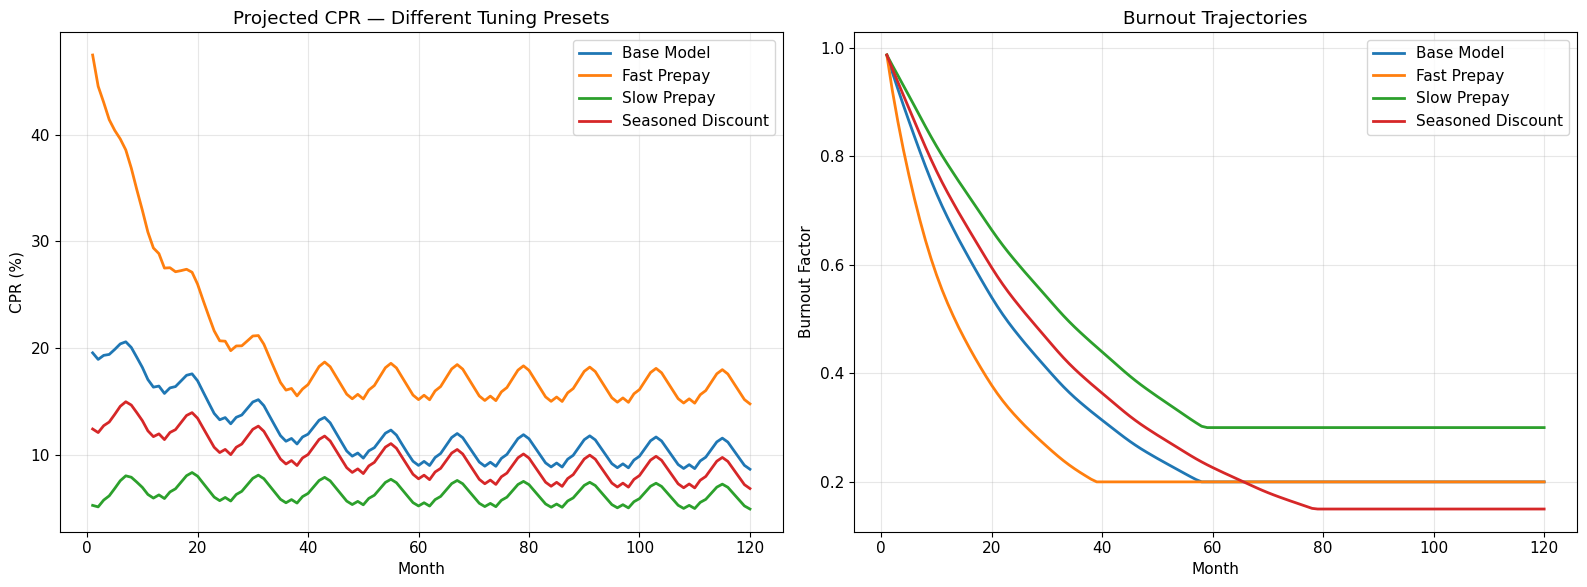

Tuning Parameter Comparison
Parameter                       Base Model Fast Prepay Slow PrepaySeasoned Discount
----------------------------------------------------------------------
refinancing_multiplier                1.00        1.30        0.70        0.50
turnover_multiplier                   1.00        1.10        0.80        1.00
refi_midpoint                         1.25        1.00        1.75        1.25
burnout_floor                         0.20        0.20        0.30        0.15


FileNotFoundError: [Errno 2] No such file or directory: '../data/base_tuning.json'

In [20]:
# Demonstrate tuning presets
presets = {
    'Base Model': PrepaymentTuning(),
    'Fast Prepay': fast_prepay_tuning(),
    'Slow Prepay': slow_prepay_tuning(),
    'Seasoned Discount': seasoned_discount_tuning()
}

cc_path = np.full(120, 0.055)  # 100bp in the money

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, tuning in presets.items():
    result = project_prepayment_rates(0.065, cc_path, 120, loan_age=30, tuning=tuning)
    axes[0].plot(result.months, result.total_cpr * 100, linewidth=2, label=name)
    axes[1].plot(result.months, result.burnout_factors, linewidth=2, label=name)

axes[0].set_xlabel('Month')
axes[0].set_ylabel('CPR (%)')
axes[0].set_title('Projected CPR — Different Tuning Presets')
axes[0].legend()

axes[1].set_xlabel('Month')
axes[1].set_ylabel('Burnout Factor')
axes[1].set_title('Burnout Trajectories')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show tuning parameters
print("Tuning Parameter Comparison")
print("=" * 70)
params_to_show = ['refinancing_multiplier', 'turnover_multiplier', 'refi_midpoint', 'burnout_floor']
print(f"{'Parameter':<30}", end='')
for name in presets: print(f"{name:>12}", end='')
print()
print("-" * 70)
for param in params_to_show:
    print(f"{param:<30}", end='')
    for name, t in presets.items():
        print(f"{getattr(t, param):>12.2f}", end='')
    print()

# Save/Load demo
base_tuning = PrepaymentTuning()
base_tuning.save('../data/base_tuning.json')
loaded = PrepaymentTuning.load('../data/base_tuning.json')
print(f"\nTuning save/load test: refi_midpoint = {loaded.refi_midpoint} (should be {base_tuning.refi_midpoint})")

---
## 7. Integration: Model-Driven Cash Flows

Now we connect the prepayment model to the cash flow engine from Notebook 02. Instead of assuming a constant CPR or PSA, the cash flow projection uses **model-generated prepayment rates** that respond to the rate environment.

This is the critical linkage for OAS: on each Monte Carlo path, the interest rate model generates a rate path → the prepayment model converts it to a CPR vector → the cash flow engine projects path-specific cash flows → we discount and average.

Model-Driven Cash Flow Comparison
Scenario                     WAL    Avg CPR    Total Int   Z-Spread @101
---------------------------------------------------------------------------
Rates Down 100bp            6.62      10.1%      392,401         153.3bp
Rates Flat                  9.45       6.9%      560,229         156.5bp
Rates Up 100bp             11.53       4.8%      683,469         155.2bp


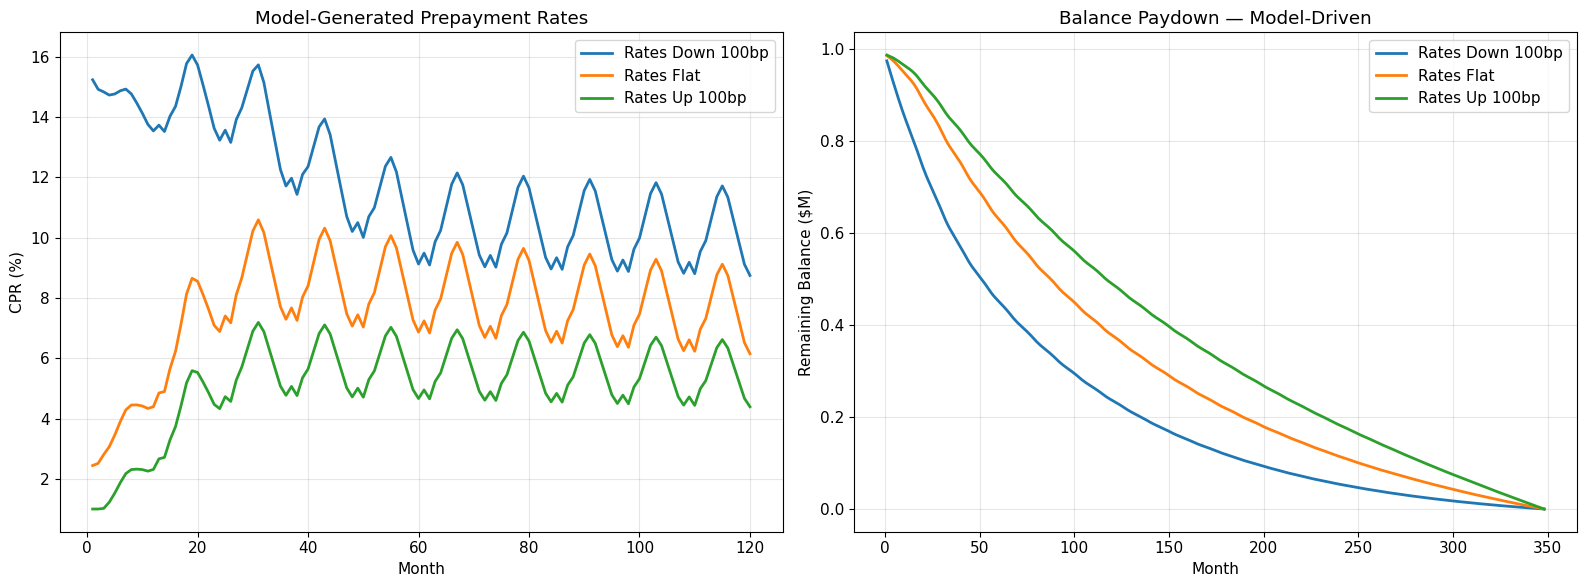


This demonstrates the model-to-cashflow pipeline that will power OAS in Notebook 07:
  Rate Path → Prepayment Model → CPR Vector → Cash Flow Engine → Discounted PV


In [23]:
from utils.cashflows import MBSPool, project_mbs_cashflows
from utils.curves import bootstrap_treasury_curve, sample_treasury_data
from utils.spreads import z_spread

# Build curves
tenors, par_yields = sample_treasury_data()
tsy_curve = bootstrap_treasury_curve(tenors, par_yields)

# Create pool
pool = MBSPool(1_000_000, 988_000, 0.065, 0.060, 348, 12, 360)

# Generate model-driven SMM vector for three rate scenarios
scenarios = {}
for label, cc_level in [('Rates Down 100bp', 0.055), ('Rates Flat', 0.060), ('Rates Up 100bp', 0.070)]:
    cc_path = np.full(pool.wam, cc_level)
    model_result = project_prepayment_rates(
        pool.wac, cc_path, pool.wam, loan_age=pool.age, tuning=PrepaymentTuning()
    )
    cf = project_mbs_cashflows(pool, smm_vector=model_result.total_smm)
    scenarios[label] = {'cf': cf, 'model': model_result}

print("Model-Driven Cash Flow Comparison")
print("=" * 75)
print(f"{'Scenario':<25} {'WAL':>6} {'Avg CPR':>10} {'Total Int':>12} {'Z-Spread @101':>15}")
print("-" * 75)

for label, data in scenarios.items():
    cf = data['cf']
    times = cf.flows['month'].values / 12.0
    cfs = cf.flows['total_cashflow'].values
    mask = cfs > 0
    z = z_spread(101.0, times[mask], cfs[mask], tsy_curve, face=pool.current_balance)
    avg_cpr = data['model'].total_cpr.mean()
    z_str = f"{z*10000:.1f}bp" if not np.isnan(z) else "N/A"
    print(f"{label:<25} {cf.weighted_avg_life:>6.2f} {avg_cpr*100:>9.1f}% {cf.total_interest:>12,.0f} {z_str:>15}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for label, data in scenarios.items():
    ax1.plot(data['model'].months[:120], data['model'].total_cpr[:120] * 100, linewidth=2, label=label)
ax1.set_xlabel('Month')
ax1.set_ylabel('CPR (%)')
ax1.set_title('Model-Generated Prepayment Rates')
ax1.legend()

for label, data in scenarios.items():
    cf = data['cf']
    ax2.plot(cf.flows['month'], cf.flows['end_balance'] / 1e6, linewidth=2, label=label)
ax2.set_xlabel('Month')
ax2.set_ylabel('Remaining Balance ($M)')
ax2.set_title('Balance Paydown — Model-Driven')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nThis demonstrates the model-to-cashflow pipeline that will power OAS in Notebook 07:")
print("  Rate Path → Prepayment Model → CPR Vector → Cash Flow Engine → Discounted PV")

---
## Summary & What's Next

### What We Built:
- **Four-component prepayment model**: refinancing (S-curve), turnover (with lock-in), burnout (population heterogeneity), aging (seasoning ramp)
- **Tuning framework**: adjustable parameters with save/load capability and presets
- **Calibration tools**: RMSE, MAE, actual/model ratios for fitting to historical data
- **Full pipeline**: rate scenario → model CPR → cash flow projection → spread analysis

### Key Insight Demonstrated:
The same pool produces dramatically different CPRs (and therefore WALs, yields, and spreads) depending on the rate environment. This rate-dependence is what makes OAS the correct valuation measure — it averages across all possible rate outcomes.

### Next: Notebook 04
CMO structuring — taking the collateral cash flows and redistributing them across tranches (sequential, PAC/companion, IO/PO strips) to create securities with very different risk profiles.